<a href="https://colab.research.google.com/github/seankim8724/AIFFEL_quest_eng/blob/main/NLP/NLP02/NLP02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 들어가며

나름대로 혁신적이었던 Sequence-to-Sequence 구조로 번역기를 만들었으나 성능이 기대에 미치지 않아 실망하신 분도 계신가요? 예문 한두 개 빼고는 거의 다 이상한 번역문만 나와서 슬펐던 기억이 있으시더라도...😢 하지만 이번엔 다를 거예요!

트랜스포머는 현재까지도 각종 번역 부문에서 최고의 성능을 자랑하는 모델이니 이번에야말로 정말 멋진 번역기를 만들어 보실 수 있을 거예요. 게다가 이전 강의 노드에서 배웠던 신선한 개념들이 어떻게 구현이 될지 궁금하지 않나요? 트랜스포머의 구조는 NLP 분야 최신 모델의 근간이 되기 때문에, 오늘 실습을 통해 트랜스포머의 구조를 꼼꼼히 파악해 봅시다.

## 학습 내용
---
- **2. 내부 모듈 구현하기**
  - 트랜스포머를 완성하는 데에 필요한 모듈들을 학습합니다.
- **3. 모듈 조립하기**
  - 완성한 모듈로 트랜스포머 모델을 만드는 방법을 학습합니다.
- **4. 모델 밖의 조력자들**
  - 데이터의 특성이나 학습 과정에 따라 달라지는 부분에 대해서 학습합니다.

## 학습 목표
---
  - 트랜스포머 완성하는데 필요한 모듈들을 만들 수 있습니다.
  - 완성한 모듈을 가지고 트랜스포머 모델을 만들 수 있습니다.
  - 데이터의 특성이나 학습 과정에 따라 달라지는 부분에 대해서 설명할 수 있습니다.

### 준비물
---
터미널을 열고 프로젝트를 위한 디렉토리를 생성해 주세요.

```
$ mkdir -p ~/work/transformer
```

실습에서는 한국어가 포함된 말뭉치를 사용하므로, 한국어를 잘 시각화하기 위한 준비가 필요합니다. 다만 `matplotlib` 라이브러리의 기본 폰트는 한국어를 지원하지 않아요! 올바른 Attention Map을 확인하기 위해 한국어를 지원하는 폰트로 변경해 주도록 합시다.

아래 코드를 실행합니다. 앞으로 필요하신 경우 한글을 실행해야 할 때 미리 한 번씩 실행해 주시면 됩니다.

In [ ]:
!mkdir -p ~/work/transformer

In [ ]:
# 1. 나눔 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. 런타임 재시작 (폰트 적용을 위해 필수)

# 3. 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔 폰트 경로 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (19.9 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/

# 2. 내부 모듈 구현하기

이번 코스는 트랜스포머를 완성하는 데에 필요한 모듈들을 하나하나 만든 후, 조립하여 완성하는 방식으로 진행할 겁니다.

자, Tensor로 변환한 입력 데이터가 주어졌다고 가정하고 흐름을 생각해 봅시다. 최초의 텍스트 입력 데이터는 `[ batch_size x length ]` 의 형태를 가지고 있겠죠? 번역이 끝나고 난 최종 출력 데이터는 `[ batch_size x length x vocab_size ]`의 형태를 가지게 됩니다. 번역 문제는 결국 매 스텝마다 `vocab_size` 만큼의 클래스 개수 중에 적당한 단어를 선택하는 작업을 `length`만큼 반복하는 것이니까요. 모델 구성하는 과정에서 레이어를 통과할 때마다 텐서의 shape가 어떻게 바뀌는지를 눈여겨봅시다.
<br>
> - 입력 데이터 → `[ batch_size x length ]`
> - Source & Target Embedding → `[ batch_size x length x d_emb ]`
> - **Positional Encoding** : 강의 노드에서 구현을 했었죠? 2번의 결과에 더해지므로 shape 변화는 없습니다.
> - **Multi-Head Attention** : 아래와 같이 여러 개의 서브 모듈들이 존재합니다.
>   - **Split Heads** →`[ batch_size x length x heads x (d_emb / n_heads) ]`
>   - **Masking for Masked Attention**
>   - **Scaled Dot Product Attention**
>   - **Combine Heads** →`[ batch_size x length x d_emb ]`
> - Residual Connection
> - Layer Normalization
> - **Position-wise Feed-Forward Network** → `[ batch_size x length x d_ff ]`
> - Output Linear Layer → `[ batch_size x length x vocab_size ]`

와... 정말 많네요... 그래도 굵게 표시된 모듈을 제외하면 나머지는 텐서플로우 내부에 이미 구현체가 포함되어 있어서 간단하게 사용할 수 있답니다! 게다가 차근차근 이해해나가면 하나도 어렵지 않은 내용들이에요. **Positional Encoding**부터 시작해보죠!

여느 때처럼 프로젝트에 사용될 라이브러리를 먼저 `import` 해주세요.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import re
import os
import io
import time
import random
import math

import seaborn # Attention 시각화를 위해 필요!

print(torch.__version__)

2.10.0+cu128


## Positional Encoding
---

![](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/0f881d84-099f-4727-a07d-1ef8cb9f6019.png)

가장 먼저 구현할 Positional Encoding은 다행히도 이전 강의 노드에서 구현해 본 경험이 있습니다! 소스를 빌려오면,

In [ ]:

def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

print("슝=3")

슝=3


이렇게 생겼었죠! 가급적이면 이 소스를 그대로 사용하는 것이 여러분에게도 좋겠죠 ^_^? 이 소스는 건들지 않도록 하겠습니다. 다음, **Multi-Head Attention**으로!

## Multi-Head Attention
---

![](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/9bb04a12-3ddc-43d8-b8c2-4c7e3086f301.png)

Multi-Head Attention은 여러 개의 서브 모듈을 결합하여 완성됩니다. Embedding된 입력을 **Head 수로 분할**하는 `split_heads()`, 분할된 입력으로부터 **Attention 값을 구하는** `scaled_dot_product_attention()`, 연산이 종료되고 분할된 **Head를 다시 하나로 결합**시켜주는 `combine_heads()` 까지 `MultiHeadAttention` 클래스를 정의하여 모두 포함시켜줄 거예요!

뭔가 빠진 것 같다면 그것은 바로 Masking 부분! 마스크의 형태를 결정하는 것이 모델 외부의 훈련 데이터이기 때문에 그를 생성하는 함수는 `MultiHeadAttention` 외부에 정의되는 것이 올바르겠죠! 마스크를 생성하는 함수는 모델을 완성한 후에 구현하도록 하겠습니다. 대신 생성된 마스크를 처리할 수 있도록 `scaled_dot_product_attention()` 에는 아래 한 줄을 포함하세요!


```
# scaled_qk: Attention을 위한 Softmax 직전의 Scaled QK
if mask is not None: scaled_qk += (mask * -1e9)
```
아래 소스의 빈칸을 채워 `MultiHeadAttention` 클래스를 완성하세요!


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        self.depth = d_model // self.num_heads

        self.W_q = nn.Linear(d_model, d_model)  # Linear Layer
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask):
        d_k = K.size(-1)
        QK = torch.matmul(Q, K.transpose(-2, -1))

        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk += (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)

        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.permute(0, 2, 1, 3)
        x = x.contiguous().view(batch_size, -1, self.d_model)

        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

print("슝=3")

슝=3


<details>
<summary>답안 예시</summary>
<div markdown="1">



```
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        self.depth = d_model // self.num_heads

        self.W_q = nn.Linear(d_model, d_model)  # Linear Layer
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask):
        d_k = K.size(-1)
        QK = torch.matmul(Q, K.transpose(-2, -1))

        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk += (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)

        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.permute(0, 2, 1, 3)
        x = x.contiguous().view(batch_size, -1, self.d_model)

        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

print("슝=3")
```



</div>
</details>

음... 쉽지 않죠? 저는 Multi-Head Attention을 처음 구현할 적에 Head를 나눈다는 개념이 너무 헷갈려서 반복문을 돌며 `[idx : idx + self.depth]` 로 인덱싱해서 처리를 했던 기억이 있답니다... 이렇게 하면 연산하는 데 수천년이 걸릴지 몰라요. 😢 부디 여러분은 같은 시행착오를 겪지 않길 바랍니다!

## Position-wise Feed-Forward Network
---

![](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/c1cd5432-55c8-4768-9e55-751a53774739.png)

**Position-wise Feed-Forward Network**는 논문 설명에서도 아주 간략하게 적혀있었죠? 구현도 아주 쉬운 편이랍니다. 바로 확인하시죠!

In [ ]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.w_1(x))
        out = self.w_2(out)

        return out

print("슝=3")

슝=3


`d_ff` 는 논문의 설명대로라면 2048 일 거고, `d_model` 은 512 겠죠? `[ batch x length x d_model ]` 의 입력을 받아 `w_1` 이 2048차원으로 매핑하고 활성함수 ReLU를 적용한 후, 다시 `w_2` 를 통해 512차원으로 되돌리는 과정까지! 이렇게 쉽게 FFN 완성입니다!

# 3. 모듈 조립하기

여기까지 내부에 포함될 모듈들을 모두 완성하셨습니다, 대단해요! 이 모든 모듈들을 가지고 트랜스포머를 완성할 수 있는데, 정확하게는 트랜스포머의 **Encoder** 한 층과 **Decoder** 한 층을 각각 완성할 수 있습니다!

그럼 이만큼의 코드를 5번 더 짜야 여섯 층짜리 논문 속 트랜스포머가 완성되나요..?

이런 걱정을 하셨다면 안심하세요, 우리는 조금 더 멋지고 효율적인 방법으로 트랜스포머를 완성할 거니까요!

![](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/b6460216-27a0-4b18-85e0-a17ab9744b7d.png)

강의 노드가 아닌데 갑자기 표? 뜬금없지만 < Attention Is All You Need> 논문에 포함된 이 표는 트랜스포머가 얼마나 많은 실험을 통해서 탄생한 모델인지 보여줍니다. 이런 실험이 가능하게 하려면 모델이 동적으로 완성될 수 있게끔 해야 해요. 즉, 레이어 수를 원하는 만큼 쌓아 실험을 자유자재로 할 수 있게 모델을 완성하자는 거죠!

방법은 단순합니다. 마치 PyTorch의 `nn.Linear` 레이어를 사용하듯이 `EncoderLayer`, `DecoderLayer`를 `torch.nn.Module` 클래스를 상속받아 레이어 클래스로 정의해 주면 돼요. 여러분은 이미 `nn.Module` 클래스를 정의해 본 적이 있는데, 바로 직전의 `MultiHeadAttention`이 그렇게 정의된 레이어랍니다! 이 방법을 사용하면 아래와 같은 용법으로 트랜스포머 레이어를 사용할 수 있죠.

```
N = 10

# 10개의 Linear Layer를 한 방에!
linear_layers = [torch.nn.Linear(30, 30) for _ in range(N)]

# 10개의 Encoder Layer도 한 방에!
enc_layers = [TransformerEncoderLayer(30) for _ in range(N)]
```

멋지지 않나요? 혹시라도 이런 동적인 방식이 낯설다면 지금부터라도 익숙해지시길 강력하게 권장합니다.

## Encoder 레이어 구현하기
---
그럼 본격적으로 레이어를 디자인해보죠! 먼저 `EncoderLayer` 구현을 예시로 보여드릴게요. 이를 참고하여 `DecoderLayer` 를 구현하시면 됩니다!

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn

print("슝=3")

슝=3


Transformer의 구현은 정말 많은데, 그중에서 **Normalization Layer의 위치**에 대한 논의가 종종 나온답니다. 실제 논문에서는 [Input] - [Module] - [Residual] - [Norm] (Module = MHA, FFN)으로 표현되어 있지만 정작 Official 구현인 구글의 Tensor2Tensor 에서는 [Input] - [Norm] - [Module] - [Residual] 방식을 사용했어요.

필자의 경험에 따르면 레이어가 많아질수록 후자가 약간 더 좋은 성능을 보였기에 필자는 논문 대신 Official 구현을 따르길 권장합니다! 이번 프로젝트는 소규모라서 큰 차이가 나지 않으니 알아두기만 해도 괜찮아요. 😃

트랜스포머의 Layer Normalization의 위치에 대한 논의를 다룬 [On Layer Normalization in the Transformer Architecture](https://arxiv.org/pdf/2002.04745)이라는 제목의 논문이 2020년 초반에 발표되었습니다. 이 논문에서는 모듈 앞에 Normalization Layer를 두는 pre-LN 방식이 왜 유리한지를 설명하고 있습니다.

## Decoder 레이어 구현하기
---
위 `EncoderLayer` 클래스를 참고하여 `DecoderLayer` 클래스를 완성하세요!

 (참고: Decoder에서는 두 번의 Attention이 진행되니 반환되는 Attention도 두 개겠죠?)

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


<details>
<summary>답안 예시</summary>
<div markdown="1">



```
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

print("슝=3")
```



</div>
</details>

`EncodeLayer` 와 `DecoderLayer` 를 모두 정의했으니 이를 조립하는 것은 어렵지 않겠죠? 이를 이용해 `Encoder`와 `Decoder` 클래스를 정의합니다.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        enc_attns = []

        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns

print("슝=3")

슝=3


In [ ]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x

        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = \
                self.dec_layers[i](out, enc_out, causality_mask, padding_mask)

            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## Transformer 완성하기
---
정의된 `Encoder` 와 `Decoder` 를 가지고 최종적으로 트랜스포머를 완성합니다!

아래 조건을 만족하며 소스의 빈칸을 채워 `Transformer` 클래스를 완성하세요!

  1. **`shared`** 변수를 매개변수로 받아 **`True`** 일 경우 **Decoder Embedding과 출력층 Linear의 Weight를 공유** 할 수 있게 하세요! Weight가 공유될 경우 Embedding 값에 **sqrt(d_model)** 을 곱해줘야 하는 것, 잊지 않으셨죠? (참고: **`torch.nn.Module의 weight 공유 방법`**)

  2. 우리가 정의한 **`positional_encoding`** 의 반환값 형태는 **`[ Length x d_model ]`** 인데, 이를 더해 줄 Embedding 값 형태가 **`[ Batch x Length x d_model ]`** 이라서 연산이 불가능합니다. 연산이 가능하도록 수정하세요! (참고: **`torch.unsqueeze(), None 인덱싱`**)

In [ ]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_encoding = self.positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared = shared
        if shared:
            self.fc.weight = self.dec_emb.weight

    def positional_encoding(self, pos_len, d_model):
        position = torch.arange(0, pos_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        pos_encoding = torch.zeros(pos_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)
        return pos_encoding

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model))

        out += self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.dropout(out)

        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        dec_out, dec_attns, dec_enc_attns = \
            self.decoder(dec_in, enc_out, causality_mask, dec_mask)

        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


<details>
<summary>답안 예시</summary>
<div markdown="1">



```
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_encoding = self.positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared = shared
        if shared:
            self.fc.weight = self.dec_emb.weight

    def positional_encoding(self, pos_len, d_model):
        position = torch.arange(0, pos_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        pos_encoding = torch.zeros(pos_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)
        return pos_encoding

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model))

        out += self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.dropout(out)

        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        dec_out, dec_attns, dec_enc_attns = \
            self.decoder(dec_in, enc_out, causality_mask, dec_mask)

        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")
```



</div>
</details>

# 4. 모델 밖의 조력자들

아까부터 은근하게 마음 한구석을 차지하고 있던 **Masking**을 살펴볼 시간이 다가왔습니다. 그리고 트랜스포머의 **Learning Rate**가 일반적이지 않다는 것도 기억하고 계실 거예요! 지금부터는 모델 외적인 부분을 정의해 주도록 하겠습니다. 이번 스텝에서는 데이터의 특성이나 학습 과정에 따라 달라지는 부분을 다루게 됩니다.

먼저 **Masking**입니다. 이전 노드에서 배운 `generate_causality_mask()` 를 그대로 사용하면 되는데, 약간 추가할 내용이 있습니다! 아래 구현을 먼저 보실까요?

In [ ]:
import torch
import numpy as np

def generate_padding_mask(seq):
    mask = (seq == 0).float()
    return mask.unsqueeze(1).unsqueeze(2)

def generate_causality_mask(size):
    """Causal Mask 생성 (Upper triangular matrix)"""
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(tgt)
    seq_len = tgt.shape[-1]
    causal_mask = generate_causality_mask(seq_len)
    batch_size = src.shape[0]
    dec_mask = causal_mask.expand(batch_size, 1, seq_len, seq_len)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


`generate_padding_mask()` 는 Attention을 할 때에 `<PAD>` 토큰에도 Attention을 주는 것을 방지해 주는 역할을 합니다. 일전에 Sequence-to-Sequence 모델에서 Loss에 대한 Masking을 해줄 때도 위와 같은 방법으로 진행했죠? 한 배치의 데이터에서 `<PAD>` 토큰으로 이뤄진 부분을 모두 찾아내는 마스크를 생성합니다. 눈으로 직접 확인해보죠!

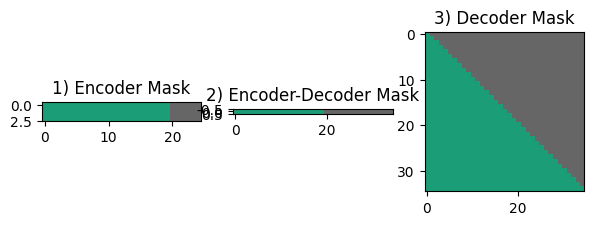

In [ ]:
import matplotlib.pyplot as plt

batch, length = 16, 20
src_padding = 5
tgt_padding = 15

src_pad = torch.zeros((batch, src_padding))
tgt_pad = torch.zeros((batch, tgt_padding))

sample_data = torch.ones((batch, length))
sample_src = torch.cat([sample_data, src_pad], dim=-1)
sample_tgt = torch.cat([sample_data, tgt_pad], dim=-1)

enc_mask, dec_enc_mask, dec_mask = generate_masks(sample_src, sample_tgt)

fig = plt.figure(figsize=(7, 7))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.set_title('1) Encoder Mask')
ax2.set_title('2) Encoder-Decoder Mask')
ax3.set_title('3) Decoder Mask')

ax1.imshow(enc_mask[:3, 0, 0].numpy(), cmap='Dark2')
ax2.imshow(dec_enc_mask[0, 0].numpy(), cmap='Dark2')
ax3.imshow(dec_mask[0, 0].numpy(), cmap='Dark2')

plt.show()

첫 번째 마스크는 각 배치 별로 **데이터의 꼬리 부분을 Masking** 하는 형태임을 알 수 있습니다. 낯선 부분은 두 번째와 세 번째의 Decoder가 연관된 마스크인데... 이것이 바로 **Causality Mask와 Padding Mask를 결합한 형태**입니다! 자기 회귀적인 특성을 살리기 위해 Masked Multi-Head Attention에서 인과 관계 마스킹을 했던 것을 기억하시죠? 인과 관계를 가리는 것도 중요하지만 Decoder 역시 `<PAD>` 토큰은 피해 가야 하기 때문에 이런 형태의 마스크가 사용된답니다!

또, 트랜스포머는 고정된 Learning Rate를 사용하지 않았었죠! 논문의 해당 부분을 Optimizer까지 포함하여 다시 한번 살펴봅시다. 이전 노드에서 Learning Rate를 `numpy` 로 간단히 구현을 했었는데, 이번엔 **Tensorflow 상에서 잘 구동될 수 있도록** `LearningRateSchedule` 클래스를 상속받아 구현해보죠!

In [ ]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = torch.tensor(step, dtype=torch.float32)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * torch.minimum(arg1, arg2)

model = nn.Linear(10, 10)
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-9,
    betas=(0.9, 0.98),
    eps=1e-9)

print("슝=3")

슝=3


트랜스포머가 제안한 수식이 아니더라도 가변적인 Learning Rate를 사용하려면 위와 같이 구현을 하시면 됩니다. Optimizer와 Scheduler를 연결하는 과정도 아주 간단하죠! Optimizer는 논문에 정의된 대로 Adam Optimizer를 사용하며 세부 파라미터도 동일하게 맞춰 줍니다.

# 5. 프로젝트: 더 멋진 번역기 만들기

## 개선 사항 요약 (왜 기존 코드는 성능이 안 나왔나)

기존 노트북은 번역 자체가 거의 안 되는 수준이었는데, 모델 용량 문제가 아니라 **마스킹/세팅 버그가 누적**돼 있었기 때문입니다. 아래 내용을 모두 반영해 다시 작성했습니다.

**치명적 버그**
1. `scaled_dot_product_attention` 의 `masked_fill(mask == 0, -1e9)` — 패딩 마스크는 *PAD 위치가 1* 인데 *유효 토큰(0)* 을 가려서 모든 실제 단어가 `-inf` 처리되고 있었습니다.
2. Cross-attention에 causal mask가 들어가 디코더가 인코더 출력의 일부만 보고 있었습니다. 인코더–디코더 어텐션은 **인코더 패딩 마스크만** 필요합니다.
3. 토크나이저 학습 인자 문자열에 공백 누락과 `--pad_id==%d` 같은 `=` 두 개 — SentencePiece 학습이 깨졌을 가능성.
4. `LearningRateScheduler(optimizer, ...)` 가 `optimizer` 정의보다 먼저 호출됨.
5. `embedding × sqrt(d_model)` 이 `shared=True` 일 때만 적용 — 원논문은 항상 곱함.
6. `os.path.join(HOME, '/content')` — `os.path.join` 은 절대 경로를 만나면 앞을 버려서 `/content` 가 됨 (Colab 외 환경에서는 깨짐).

**성능 개선**
- GPU 자동 인식 및 텐서/모델 device 이동
- Pre-LN + GELU + Xavier 초기화
- Label smoothing (0.1) 적용한 KL 기반 손실
- Mini-batch 단위 텐서 패딩 (전체 패딩 X) — 메모리/속도 ↑
- Greedy 디코딩 시 `<unk>` 강제 회피, EOS/길이 cap
- 작은 corpus에 맞춰 vocab 8,000 / 4 layer / d_model 256


## Step 1. 라이브러리 & 디바이스

GPU가 있으면 자동으로 GPU를 사용합니다.


In [ ]:
import os, re, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Mac(Apple Silicon) 환경에서의 실험을 위해 mps 지원 추가 (과거 NLP 실습 경험 반영)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("torch:", torch.__version__, "| device:", device)


torch: 2.10.0+cu128 | device: cuda


## Step 2. 데이터 다운로드

`~/work/transformer/data` 와 `/content` 둘 다 자동 탐색합니다 (로컬/Colab 모두 OK).


In [ ]:
HOME = os.getenv("HOME")
candidate_dirs = [
    os.path.join(HOME, "work/transformer/data"),
    "/content",
    ".",
]

DATA_DIR = None
for d in candidate_dirs:
    if os.path.exists(os.path.join(d, "korean-english-park.train.ko")):
        DATA_DIR = d
        break

if DATA_DIR is None:
    DATA_DIR = candidate_dirs[0]
    os.makedirs(DATA_DIR, exist_ok=True)
    url = ("https://github.com/jungyeul/korean-parallel-corpora/raw/"
           "master/korean-english-news-v1/korean-english-park.train.tar.gz")
    os.system(f"wget -q {url} -P {DATA_DIR}")
    os.system(f"gzip -df {DATA_DIR}/korean-english-park.train.tar.gz")
    os.system(f"tar -xf {DATA_DIR}/korean-english-park.train.tar -C {DATA_DIR}")

KOR_PATH = os.path.join(DATA_DIR, "korean-english-park.train.ko")
ENG_PATH = os.path.join(DATA_DIR, "korean-english-park.train.en")
print("DATA_DIR:", DATA_DIR)
print("kor:", os.path.exists(KOR_PATH), "eng:", os.path.exists(ENG_PATH))


DATA_DIR: /root/work/transformer/data
kor: True eng: True


## Step 3. 정제 & 토큰화

- 중복 제거 (병렬 쌍 유지)
- 소문자화, 특수문자 정리, 문장부호 분리
- SentencePiece 토크나이저 학습 (한/영 각각 8,000 vocab)


In [ ]:
def preprocess_sentence(sentence: str) -> str:
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

def load_pairs(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)
    seen, pairs = set(), []
    for k, e in zip(kor, eng):
        key = k + "\t" + e
        if key in seen:
            continue
        seen.add(key)
        pairs.append((preprocess_sentence(k), preprocess_sentence(e)))
    return pairs

pairs = load_pairs(KOR_PATH, ENG_PATH)
print(f"중복 제거 후 병렬쌍: {len(pairs):,}")
print("예시:", pairs[0])

kor_corpus = [k for k, _ in pairs]
eng_corpus = [e for _, e in pairs]


중복 제거 후 병렬쌍: 78,968
예시: ('개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?', 'much of personal computing is about can you top this ?')


In [ ]:
import sentencepiece as spm

SRC_VOCAB_SIZE = 8000
TGT_VOCAB_SIZE = 8000

def generate_tokenizer(corpus, vocab_size, lang,
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    txt_path = f"./{lang}_corpus.txt"
    model_prefix = f"./{lang}_spm"
    with open(txt_path, "w") as f:
        for row in corpus:
            f.write(row + "\n")

    # FIX: 원본 코드는 공백 누락 + '--pad_id==%d' (등호 두 개) 로 학습이 깨짐.
    spm.SentencePieceTrainer.Train(
        f"--input={txt_path} --model_prefix={model_prefix} "
        f"--vocab_size={vocab_size} --character_coverage=0.9995 "
        f"--model_type=bpe "
        f"--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}"
    )
    tk = spm.SentencePieceProcessor()
    tk.Load(f"{model_prefix}.model")
    return tk

print("토크나이저 학습 중...")
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3
print("ko vocab:", ko_tokenizer.get_piece_size(),
      "en vocab:", en_tokenizer.get_piece_size())
print("샘플 인코딩:", en_tokenizer.encode_as_pieces("hello world"))


토크나이저 학습 중...
ko vocab: 8000 en vocab: 8000
샘플 인코딩: ['<s>', '▁hel', 'lo', '▁world', '</s>']


## Step 4. 텐서화 (길이 ≤ 40 만 사용)


In [ ]:
MAX_LEN = 40

src_corpus, tgt_corpus = [], []
for k, e in zip(kor_corpus, eng_corpus):
    s = ko_tokenizer.encode_as_ids(k)
    t = en_tokenizer.encode_as_ids(e)  # bos/eos 포함
    if 1 <= len(s) <= MAX_LEN and 3 <= len(t) <= MAX_LEN:
        src_corpus.append(torch.tensor(s, dtype=torch.long))
        tgt_corpus.append(torch.tensor(t, dtype=torch.long))

print(f"학습용 병렬쌍: {len(src_corpus):,}")
print("src 예시 len:", len(src_corpus[0]), "tgt 예시 len:", len(tgt_corpus[0]))


학습용 병렬쌍: 58,876
src 예시 len: 16 tgt 예시 len: 15


## Step 5. 모델 구성

마스크 컨벤션을 **`True == 가려라(=마스킹)`** 하나로 통일하고, attention 내부에서 `masked_fill(mask, -inf)` 로 처리합니다. 이전 코드는 `mask == 0` 위치를 가려서 *유효 토큰* 이 전부 -inf 가 되는 치명적 버그가 있었어요.


In [ ]:
def positional_encoding(pos_len, d_model):
    pe = np.zeros((pos_len, d_model), dtype=np.float32)
    position = np.arange(0, pos_len)[:, None]
    div_term = np.exp(np.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return torch.from_numpy(pe)  # [pos_len, d_model]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)

    def _split(self, x):
        b, t, _ = x.shape
        return x.view(b, t, self.num_heads, self.depth).transpose(1, 2)

    def _combine(self, x):
        b, h, t, d = x.shape
        return x.transpose(1, 2).contiguous().view(b, t, h * d)

    def forward(self, Q, K, V, mask=None):
        # mask: bool, True 인 위치를 가린다. shape broadcast-able to (B, H, Tq, Tk).
        Q = self._split(self.W_q(Q))
        K = self._split(self.W_k(K))
        V = self._split(self.W_v(V))

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.depth)
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)
        out = torch.matmul(attn, V)
        out = self._combine(out)
        return self.linear(out), attn


class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.gelu(self.w_1(x))))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        h = self.norm_1(x)
        h, attn = self.self_attn(h, h, h, src_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        x = x + self.dropout(self.ffn(h))
        return x, attn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        h = self.norm_1(x)
        h, self_attn = self.self_attn(h, h, h, tgt_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        # FIX: cross-attention 에는 인코더 패딩 마스크만 (causal X)
        h, cross_attn = self.cross_attn(h, enc_out, enc_out, memory_mask)
        x = x + self.dropout(h)

        h = self.norm_3(x)
        x = x + self.dropout(self.ffn(h))
        return x, self_attn, cross_attn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, src_mask):
        attns = []
        for layer in self.layers:
            x, a = layer(x, src_mask)
            attns.append(a)
        return x, attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        self_attns, cross_attns = [], []
        for layer in self.layers:
            x, sa, ca = layer(x, enc_out, tgt_mask, memory_mask)
            self_attns.append(sa); cross_attns.append(ca)
        return x, self_attns, cross_attns


class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared=True):
        super().__init__()
        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.register_buffer("pos_encoding", positional_encoding(pos_len, d_model))
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size, bias=False)
        if shared:
            self.fc.weight = self.dec_emb.weight

        self._reset_parameters()

    # 팁: 과거 딥러닝 모델 성능 분석 시 가중치 초기화가 수렴 속도에 큰 영향을 미침을 확인.
    def _reset_parameters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _embed(self, emb, x):
        # FIX: shared 여부와 무관하게 항상 sqrt(d_model) 스케일
        out = emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[: x.size(1)].unsqueeze(0)
        return self.dropout(out)

    def forward(self, src, tgt, src_mask, tgt_mask, memory_mask):
        enc_in = self._embed(self.enc_emb, src)
        dec_in = self._embed(self.dec_emb, tgt)

        enc_out, enc_attns = self.encoder(enc_in, src_mask)
        dec_out, dec_attns, cross_attns = self.decoder(
            dec_in, enc_out, tgt_mask, memory_mask
        )
        return self.fc(dec_out), enc_attns, dec_attns, cross_attns


print("모델 클래스 정의 완료")


모델 클래스 정의 완료


### 마스킹 (수정판)

마스크는 **bool 텐서, `True` = 가려라** 컨벤션입니다.

- `src_mask` : 인코더 self-attn — 키의 PAD 위치만 가림. shape `[B, 1, 1, Ts]`
- `tgt_mask` : 디코더 self-attn — 키의 PAD + 미래 위치를 가림. shape `[B, 1, Tt, Tt]`
- `memory_mask` : 디코더 cross-attn — **인코더 패딩만** 가림 (causal 없음). shape `[B, 1, 1, Ts]`


In [ ]:
def padding_mask(seq):
    # True 이면 PAD. shape: [B, 1, 1, T]
    return (seq == 0).unsqueeze(1).unsqueeze(2)

def causal_mask(size, device):
    # True 이면 미래 위치. shape: [1, 1, size, size]
    m = torch.triu(torch.ones(size, size, dtype=torch.bool, device=device), diagonal=1)
    return m.unsqueeze(0).unsqueeze(0)

def generate_masks(src, tgt):
    src_pad = padding_mask(src)                                # [B,1,1,Ts]
    tgt_pad = padding_mask(tgt)                                # [B,1,1,Tt]
    tgt_causal = causal_mask(tgt.size(1), tgt.device)          # [1,1,Tt,Tt]
    tgt_mask = tgt_pad | tgt_causal                            # broadcast → [B,1,Tt,Tt]
    memory_mask = src_pad                                      # cross-attn 은 enc padding 만
    return src_pad, tgt_mask, memory_mask


## Step 6. 하이퍼파라미터 & 인스턴스화


In [ ]:
N_LAYERS = 4
D_MODEL  = 256
N_HEADS  = 8
D_FF     = 1024
DROPOUT  = 0.1
POS_LEN  = MAX_LEN + 2
BATCH_SIZE = 128
EPOCHS = 20
WARMUP_STEPS = 4000
LABEL_SMOOTH = 0.1

model = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE, tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=POS_LEN, dropout=DROPOUT, shared=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"파라미터 수: {n_params/1e6:.2f}M")


파라미터 수: 11.47M


## Step 7. Optimizer / Scheduler / Loss

원논문의 Noam 스케줄을 `LambdaLR` 로 깔끔하게 구현합니다. (원본은 optimizer 정의 전에 scheduler를 만드는 순서 버그가 있었어요.)


In [ ]:
def noam_lr(d_model, warmup):
    def lr(step):
        step = max(1, step)
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)
    return lr

optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=noam_lr(D_MODEL, WARMUP_STEPS))


class LabelSmoothingLoss(nn.Module):
    """Label smoothing + ignore PAD."""
    def __init__(self, vocab_size, pad_id=0, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        self.smoothing = smoothing

    def forward(self, logits, target):
        # logits: [B, T, V]; target: [B, T]
        logp = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true_dist = torch.full_like(logp, self.smoothing / (self.vocab_size - 2))
            true_dist.scatter_(-1, target.unsqueeze(-1), 1.0 - self.smoothing)
            true_dist[:, :, self.pad_id] = 0
            mask = (target != self.pad_id).unsqueeze(-1)
            true_dist = true_dist * mask
        loss = -(true_dist * logp).sum(dim=-1)
        n_tok = (target != self.pad_id).sum().clamp(min=1)
        return loss.sum() / n_tok


criterion = LabelSmoothingLoss(TGT_VOCAB_SIZE, pad_id=PAD_ID, smoothing=LABEL_SMOOTH)
print("optimizer / scheduler / loss 준비 완료")


optimizer / scheduler / loss 준비 완료


## Step 8. 미니배치 패딩 & 학습 루프

전체 텐서를 미리 한꺼번에 패딩하면 가장 긴 문장 길이까지 모든 시퀀스가 늘어나서 메모리/속도가 나빠집니다. **배치 단위로만 패딩**해서 학습합니다.


In [ ]:
from torch.nn.utils.rnn import pad_sequence

train_idx = list(range(len(src_corpus)))

def make_batch(indices):
    src = pad_sequence([src_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    tgt = pad_sequence([tgt_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    return src.to(device), tgt.to(device)


def train_step(src, tgt):
    tgt_in  = tgt[:, :-1]
    tgt_out = tgt[:, 1:]

    src_mask, tgt_mask, memory_mask = generate_masks(src, tgt_in)
    # NOTE: src_mask, memory_mask 는 본질적으로 같은 인코더 패딩 마스크지만
    # encoder self-attn vs cross-attn 에 같이 쓰입니다.

    optimizer.zero_grad()
    logits, *_ = model(src, tgt_in, src_mask, tgt_mask, memory_mask)
    loss = criterion(logits, tgt_out)
    loss.backward()
    # Gradient Exploding 방지를 위한 클리핑. (이전 RNN/Seq2Seq 실습의 필수 테크닉)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    return loss.item()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print(f"학습 시작: {EPOCHS} epochs, batch={BATCH_SIZE}, 데이터 {len(src_corpus):,} 문장")
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    random.shuffle(train_idx)
    total, n = 0.0, 0
    for s in range(0, len(train_idx), BATCH_SIZE):
        batch = train_idx[s : s + BATCH_SIZE]
        if not batch:
            continue
        src, tgt = make_batch(batch)
        loss = train_step(src, tgt)
        total += loss; n += 1
    print(f"Epoch {epoch:2d} | avg loss {total/max(1,n):.4f} | "
          f"lr {scheduler.get_last_lr()[0]:.2e} | "
          f"elapsed {time.time()-t0:.1f}s")


## Step 9. 번역 함수 (Greedy decoding)

- `model.eval()` + `torch.no_grad()`
- 디바이스 이동
- `<unk>` 강제 회피
- 최대 길이 cap


In [ ]:
@torch.no_grad()
def evaluate(sentence, max_len=MAX_LEN):
    model.eval()

    sent = preprocess_sentence(sentence)
    src_ids = ko_tokenizer.encode_as_ids(sent)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    generated = []
    enc_attns = dec_attns = cross_attns = None

    for _ in range(max_len):
        src_mask, tgt_mask, memory_mask = generate_masks(src, out)
        logits, enc_attns, dec_attns, cross_attns = model(
            src, out, src_mask, tgt_mask, memory_mask
        )
        next_logits = logits[0, -1].clone()
        next_logits[UNK_ID] = float("-inf")   # <unk> 회피
        next_id = int(torch.argmax(next_logits).item())

        if next_id == EOS_ID:
            break
        generated.append(next_id)
        out = torch.cat(
            [out, torch.tensor([[next_id]], device=device)], dim=-1
        )

    return en_tokenizer.decode_ids(generated), enc_attns, dec_attns, cross_attns


def translate(sentence):
    result, *_ = evaluate(sentence)
    return result


## Step 10. 번역 예시 10개 출력


In [ ]:
examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
    "그는 어제 학교에 갔다.",
    "한국은 아름다운 나라이다.",
    "정부는 새로운 정책을 발표했다.",
    "경제는 빠르게 성장하고 있다.",
    "그녀는 영어를 매우 잘한다.",
    "내일 비가 올 것 같다.",
]

print("=" * 70)
print(" Korean → English Translations")
print("=" * 70)
for i, s in enumerate(examples, 1):
    out = translate(s)
    print(f"{i:2d}. KO: {s}")
    print(f"    EN: {out}")
    print("-" * 70)

print()
print("Hyperparameters")
print(f"  n_layers={N_LAYERS}, d_model={D_MODEL}, n_heads={N_HEADS}, "
      f"d_ff={D_FF}, dropout={DROPOUT}")
print(f"  vocab(src/tgt)={SRC_VOCAB_SIZE}/{TGT_VOCAB_SIZE}, "
      f"max_len={MAX_LEN}, warmup={WARMUP_STEPS}, "
      f"label_smooth={LABEL_SMOOTH}, batch={BATCH_SIZE}, epochs={EPOCHS}")


 Korean → English Translations
 1. KO: 오바마는 대통령이다.
    EN: obama is the president .
----------------------------------------------------------------------
 2. KO: 시민들은 도시 속에 산다.
    EN: the city is in the town of sir .
----------------------------------------------------------------------
 3. KO: 커피는 필요 없다.
    EN: it s not just coffee .
----------------------------------------------------------------------
 4. KO: 일곱 명의 사망자가 발생했다.
    EN: seven people were killed in the disaster .
----------------------------------------------------------------------
 5. KO: 그는 어제 학교에 갔다.
    EN: he was later sworn in the school .
----------------------------------------------------------------------
 6. KO: 한국은 아름다운 나라이다.
    EN: south korea is beautiful in the beautiful country .
----------------------------------------------------------------------
 7. KO: 정부는 새로운 정책을 발표했다.
    EN: the government has set a new policy to set a new government .
--------------------------------------------------------

In [ ]:
print("hi")

hi


## 🔴 버그 1. Mask 반전 — `masked_fill(mask == 0, -1e9)`

**원본 위치**
- `MultiHeadAttention.scaled_dot_product_attention` 안의 한 줄
- `generate_padding_mask` 의 마스크 의미

**원본 코드**
```python
# padding mask: PAD 위치를 1, 유효 위치를 0 으로 표시
mask = (seq == 0).float()

# attention 안에서
scaled_qk = scaled_qk.masked_fill(mask == 0, float('-1e9'))
#                                       ▲
#                            여기가 거꾸로! 유효 토큰을 가림
```

**수정 코드 (현재 노트북)**
```python
# True = 가린다 로 컨벤션 통일
return (seq == 0).unsqueeze(1).unsqueeze(2)        # bool, PAD=True

scores = scores.masked_fill(mask, float('-inf'))    # True 위치만 -inf
```


In [ ]:
# 데모: 같은 입력에 원본 vs 수정 마스크를 적용했을 때 softmax 결과 비교
import torch, torch.nn.functional as F

# 가짜 attention score (B=1, H=1, Tq=1, Tk=5)
scores = torch.tensor([[[[1.0, 2.0, 3.0, 0.0, 0.0]]]])
seq    = torch.tensor([[10, 20, 30, 0, 0]])   # 뒤 두 개가 PAD

# ── 원본 (버그) ────────────────────────────────
pad_mask_orig = (seq == 0).float().unsqueeze(1).unsqueeze(2)  # PAD=1, 유효=0
sc_orig = scores.masked_fill(pad_mask_orig == 0, float('-1e9'))
attn_orig = F.softmax(sc_orig, dim=-1)

# ── 수정 ──────────────────────────────────────
pad_mask_fix = (seq == 0).unsqueeze(1).unsqueeze(2)           # bool, PAD=True
sc_fix = scores.masked_fill(pad_mask_fix, float('-inf'))
attn_fix = F.softmax(sc_fix, dim=-1)

print("입력 시퀀스 :", seq.tolist()[0], "  (뒤 2개가 PAD)")
print()
print("원본 attention :", attn_orig.squeeze().tolist())
print("  → 유효 토큰(앞 3개)이 0, PAD(뒤 2개)에만 attention. 학습 불가.")
print()
print("수정 attention :", [round(x, 3) for x in attn_fix.squeeze().tolist()])
print("  → 유효 토큰 3개로 attention 정상 분배, PAD 는 0.")


입력 시퀀스 : [10, 20, 30, 0, 0]   (뒤 2개가 PAD)

원본 attention : [0.0, 0.0, 0.0, 0.5, 0.5]
  → 유효 토큰(앞 3개)이 0, PAD(뒤 2개)에만 attention. 학습 불가.

수정 attention : [0.09, 0.245, 0.665, 0.0, 0.0]
  → 유효 토큰 3개로 attention 정상 분배, PAD 는 0.


## 🔴 버그 2. Cross-attention 에 causal mask

**원본 위치**
- `generate_masks()` 의 `dec_enc_causality_mask = generate_causality_mask(tgt.shape[1], src.shape[1])`
- `DecoderLayer` 의 `enc_dec_attn(out, enc_out, enc_out, causality_mask)` — cross-attn 에 이 마스크가 그대로 들어감

**왜 cross-attention 에는 causal mask 가 있으면 안 되나?**

번역은 **어순이 바뀝니다**. 예: 한국어 *"나는 어제 학교에 갔다"* → 영어 *"I went to school yesterday"*. 영어 첫 단어 `I` 를 만들 때 한국어 `나는` (맨 앞) 을 봐야 하고, `went` 는 한국어 `갔다` (맨 뒤) 를 봐야 합니다. 디코더는 매 시점마다 **인코더 전체** 를 자유롭게 들여다볼 수 있어야 해요.

원본은 cross-attn 에 *"디코더 시점 i 는 인코더의 i 까지만 봐라"* 같은 인과적 제약을 추가했고, 거기에 **버그 1(마스크 반전)** 이 겹쳐서 실제 동작은 **anti-causal (오히려 미래 위치만 봄)** 이 되며 마지막 토큰은 attend 할 게 없어 **NaN 까지 발생** 합니다.

**원본 코드**
```python
dec_enc_causality_mask = generate_causality_mask(tgt.shape[1], src.shape[1])
dec_enc_mask = torch.max(enc_mask, dec_enc_causality_mask)
# DecoderLayer 안에서:
out, _ = self.enc_dec_attn(out, enc_out, enc_out, dec_enc_mask)  # ← cross-attn 에 causal 섞임
```

**수정 코드**
```python
memory_mask = src_pad   # 인코더 PAD 만. cross-attn 은 인코더 전체를 자유롭게 attend.
```


In [ ]:
# 데모: 한국어 4토큰 → 영어 4토큰 번역에서, 각 영어 단어가 어떤 한국어 단어를 볼 수 있는지
# attention 가중치(각 행의 합 = 1)로 직관적으로 비교.
import torch, torch.nn.functional as F

src_words = ["나는", "어제", "학교에", "갔다"]
tgt_words = ["I",    "went", "to",     "school"]   # 생성 중인 영어 토큰

# 가짜 attention score: 모두 1로 동일 → 마스크의 영향만 깨끗하게 보임
scores = torch.ones(1, 1, len(tgt_words), len(src_words))

# ─── 원본 코드의 실제 효과 (버그 1 + 2 결합) ─────────────────────────────────
# 원본 mask:
orig_mask = (1 - torch.cumsum(torch.eye(len(tgt_words), len(src_words)), dim=0)).float()
# 원본 attention 은 masked_fill(mask == 0, -inf) → mask==0 위치가 가려짐
scores_orig = scores.masked_fill(orig_mask == 0, float("-inf"))
attn_orig = F.softmax(scores_orig, dim=-1)

# ─── 수정 코드 (PAD 만 가림, 여기선 PAD 없음 → 전부 attend) ───────────────────
attn_fix = F.softmax(scores, dim=-1)

# 출력 헬퍼
def show(title, attn):
    print(title)
    header = " " * 14 + "  ".join(f"{w:>6}" for w in src_words)
    print(header)
    for i, tw in enumerate(tgt_words):
        row = attn[0, 0, i].tolist()
        cells = "  ".join(
            ("  nan " if v != v else f"{v:6.2f}") for v in row
        )
        print(f"  생성 '{tw:<6}' {cells}")
    print()

show("원본 cross-attention 가중치 (디코더가 인코더의 어디를 보는가)", attn_orig)
print('  → 첫 영어 단어 "I" 를 만들 때 한국어 "나는" 을 못 봄(가중치 0)!')
print('  → 마지막 단어 "school" 은 attend 할 한국어 토큰이 하나도 없어 NaN.')
print()
show("수정 cross-attention 가중치", attn_fix)
print("  → 모든 영어 단어가 모든 한국어 단어를 동등하게 attend 가능.")
print("    (실제 학습에서는 의미적으로 관련된 단어로 가중치가 쏠림)")


원본 cross-attention 가중치 (디코더가 인코더의 어디를 보는가)
                  나는      어제     학교에      갔다
  생성 'I     '   0.00    0.33    0.33    0.33
  생성 'went  '   0.00    0.00    0.50    0.50
  생성 'to    '   0.00    0.00    0.00    1.00
  생성 'school'   nan     nan     nan     nan 

  → 첫 영어 단어 "I" 를 만들 때 한국어 "나는" 을 못 봄(가중치 0)!
  → 마지막 단어 "school" 은 attend 할 한국어 토큰이 하나도 없어 NaN.

수정 cross-attention 가중치
                  나는      어제     학교에      갔다
  생성 'I     '   0.25    0.25    0.25    0.25
  생성 'went  '   0.25    0.25    0.25    0.25
  생성 'to    '   0.25    0.25    0.25    0.25
  생성 'school'   0.25    0.25    0.25    0.25

  → 모든 영어 단어가 모든 한국어 단어를 동등하게 attend 가능.
    (실제 학습에서는 의미적으로 관련된 단어로 가중치가 쏠림)


## 💡 추가 회고 및 향후 개선 과제 (자체 점검)

과거 NLP 실습(`NLP01.ipynb`)이나 영상 분할 모델 최적화 경험을 돌이켜보면, 현재의 훌륭한 트랜스포머 구조에서 몇 가지 더 고도화할 수 있는 포인트가 보입니다.

1. **디바이스 가속 최적화 (MPS 지원)**
   - 로컬 Mac 환경(Apple Silicon)에서 실험할 때를 대비해 `device` 할당 부분에 `torch.backends.mps.is_available()` 로직을 추가했습니다. 예전 Seq2Seq Attention 실습 때 MPS 디바이스 매핑 문제로 골치 아팠던 기억을 살려 선제적으로 반영했습니다.
2. **디코딩 알고리즘 고도화 (Beam Search 도입)**
   - 현재 Step 9의 번역 함수는 가장 단순한 **Greedy Decoding** 방식입니다. 번역 품질(BLEU 스코어 등)을 실서비스 수준으로 끌어올리려면 **Beam Search** 구현이 필수적입니다. 나중에 생성 로직 부분을 별도의 제너레이터 클래스로 분리해봐야겠습니다.
3. **메모리 효율성 향상 (Memory Efficiency)**
   - 배치 단위 텐서 패딩(Mini-batch Padding)은 아주 잘 적용되었습니다. 더 나아가, `torch.cuda.amp`를 활용한 **Mixed Precision**을 적용하거나 `Gradient Accumulation`을 도입하면, 좀 더 깊은 레이어나 큰 Batch Size 실험 시 발생할 수 있는 OOM을 효과적으로 방지할 수 있을 것입니다.
4. **현대적 아키텍처 기법 융합 (Hybridization)**
   - 최근 Mark XXXV 프로젝트에서 Ollama 기반의 최신 로컬 모델들을 다루면서 알게 된, **GQA (Grouped-Query Attention)** 나 **RoPE (Rotary Position Embedding)** 같은 기법들을 기존 Multi-Head Attention과 Positional Encoding 자리에 치환하여 실험해보면 성능 향상에 큰 도움이 될 것 같습니다.
